In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Setup paths
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DB_PATH = PROJECT_ROOT / 'data' / 'credit_risk.duckdb'
FIG_PATH = PROJECT_ROOT / 'notebooks'
FIG_PATH.mkdir(exist_ok=True)

# Setup plotting
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    plt.style.use('seaborn-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

conn = duckdb.connect(str(DB_PATH), read_only=True)
print(f"Connected to: {DB_PATH}")

Connected to: /home/andrea/credit-risk-lakehouse/data/credit_risk.duckdb


## 1. Overview Dataset

In [2]:
# Companies in dataset
companies = conn.execute("""
    SELECT c.name, COUNT(r.period_end) as periods,
           MIN(r.period_end) as first_period,
           MAX(r.period_end) as last_period
    FROM companies c
    JOIN ratios r ON c.cik = r.cik
    GROUP BY c.name
    ORDER BY c.name
""").fetchdf()

print(f"Companies: {len(companies)}")
print(f"Total periods: {companies['periods'].sum()}")
print(f"\n{companies.to_string(index=False)}")

Companies: 20
Total periods: 60

                                name  periods first_period last_period
                      AMAZON COM INC        3   2022-12-31  2024-12-31
                       Alphabet Inc.        3   2022-12-31  2024-12-31
                          Apple Inc.        3   2023-09-30  2025-09-27
           BANK OF AMERICA CORP /DE/        3   2022-12-31  2024-12-31
                           BOEING CO        3   2022-12-31  2024-12-31
                        CHEVRON CORP        3   2022-12-31  2024-12-31
                 CISCO SYSTEMS, INC.        3   2023-07-29  2025-07-26
                        COCA COLA CO        3   2022-12-31  2024-12-31
                    EXXON MOBIL CORP        3   2022-12-31  2024-12-31
                          INTEL CORP        3   2022-12-31  2024-12-28
INTERNATIONAL BUSINESS MACHINES CORP        3   2022-12-31  2024-12-31
                   JOHNSON & JOHNSON        3   2023-01-01  2024-12-29
                 JPMORGAN CHASE & CO        

## 2. Financial Ratio Distributions

In [3]:
# Load all ratios with company name
df = conn.execute("""
    SELECT c.name as company, r.*
    FROM ratios r
    JOIN companies c ON r.cik = c.cik
    WHERE r.period_end >= '2024-01-01'
""").fetchdf()

print(f"Recent periods (2024+): {len(df)}")

Recent periods (2024+): 26


In [4]:
# Descriptive statistics
ratios_cols = ['current_ratio', 'debt_to_equity', 'debt_to_assets', 
               'gross_margin', 'operating_margin', 'net_margin', 'roe', 'roa']

stats = df[ratios_cols].describe().T
stats['missing'] = df[ratios_cols].isna().sum()
print("\n=== Ratio Statistics (2024+) ===\n")
print(stats.round(3).to_string())


=== Ratio Statistics (2024+) ===

                  count   mean    std     min    25%    50%    75%     max  missing
current_ratio      24.0  1.470  1.002   0.704  0.905  1.087  1.334   4.440        2
debt_to_equity     21.0  0.363  9.926 -41.013  0.664  1.395  1.737  10.611        5
debt_to_assets     21.0  0.584  0.224   0.278  0.403  0.585  0.795   1.025        5
gross_margin       14.0  0.531  0.230  -0.030  0.464  0.629  0.690   0.750       12
operating_margin   19.0  0.234  0.221  -0.220  0.090  0.226  0.371   0.624        7
net_margin         26.0  0.183  0.190  -0.353  0.094  0.185  0.282   0.558        0
roe                26.0  0.464  0.666  -0.189  0.173  0.224  0.338   3.024        0
roa                26.0  0.132  0.157  -0.095  0.059  0.083  0.170   0.653        0


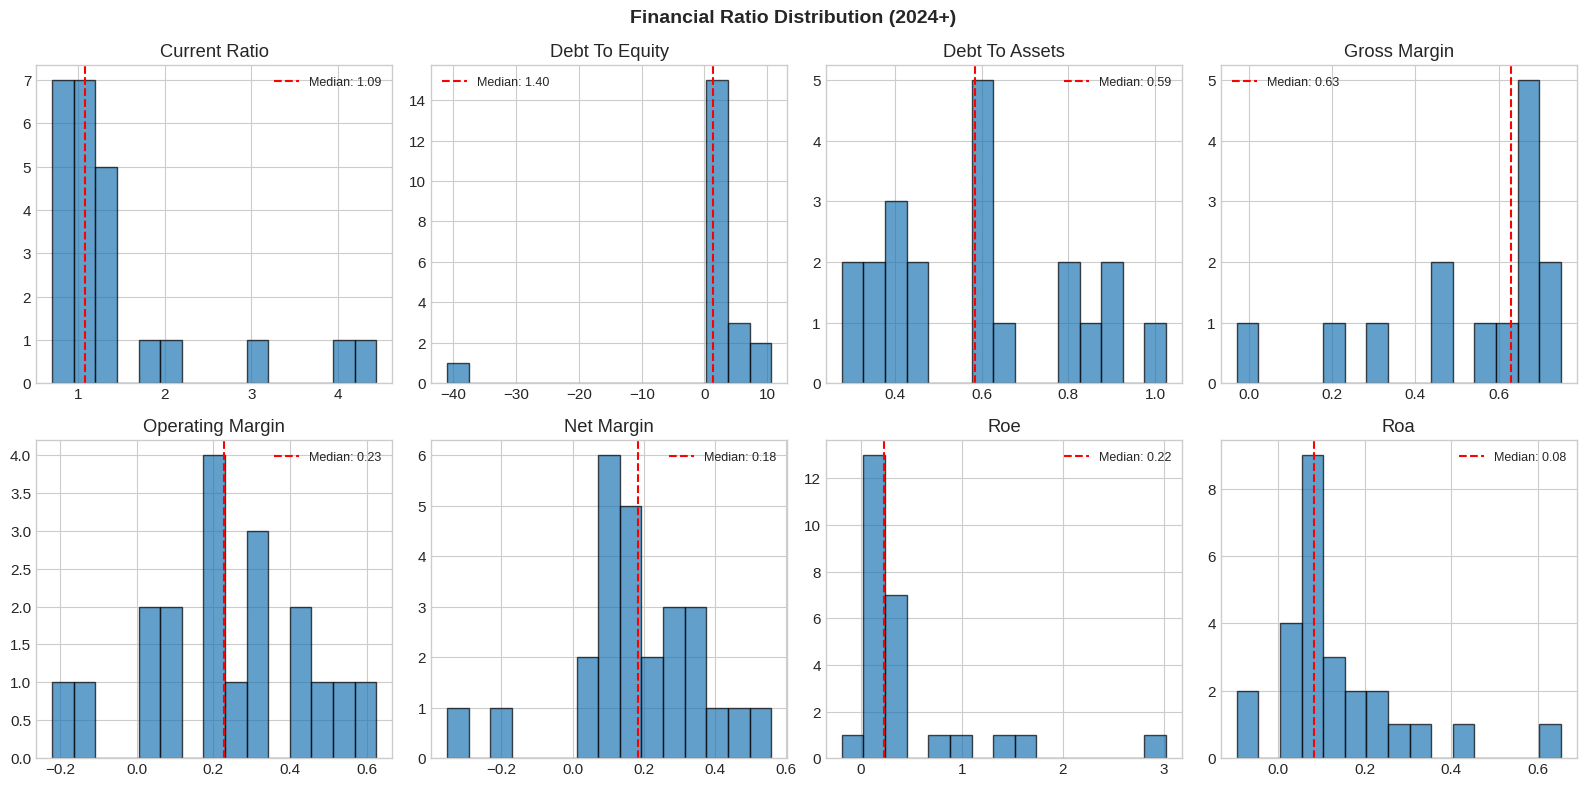

In [5]:
# Visual distribution
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(ratios_cols):
    ax = axes[i]
    data = df[col].dropna()
    
    ax.hist(data, bins=15, edgecolor='black', alpha=0.7)
    ax.axvline(data.median(), color='red', linestyle='--', label=f'Median: {data.median():.2f}')
    ax.set_title(col.replace('_', ' ').title())
    ax.legend(fontsize=9)

plt.suptitle('Financial Ratio Distribution (2024+)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_PATH / 'fig_distributions.png', dpi=150)
plt.show()

## 3. Company Ranking by Ratio

In [6]:
# Latest period available for each company
latest = conn.execute("""
    WITH ranked AS (
        SELECT c.name as company, r.*,
               ROW_NUMBER() OVER (PARTITION BY r.cik ORDER BY r.period_end DESC) as rn
        FROM ratios r
        JOIN companies c ON r.cik = c.cik
    )
    SELECT * FROM ranked WHERE rn = 1
""").fetchdf()

print("=== ROE Ranking (latest period) ===\n")
roe_rank = latest[['company', 'period_end', 'roe']].dropna().sort_values('roe', ascending=False)
roe_rank['roe_pct'] = (roe_rank['roe'] * 100).round(1).astype(str) + '%'
print(roe_rank[['company', 'period_end', 'roe_pct']].to_string(index=False))

=== ROE Ranking (latest period) ===

                             company period_end roe_pct
                           BOEING CO 2024-12-31  302.4%
                          Apple Inc. 2025-09-27  151.9%
                         NVIDIA CORP 2025-01-26   91.9%
                        COCA COLA CO 2024-12-31   42.8%
                Meta Platforms, Inc. 2024-12-31   34.1%
                       Alphabet Inc. 2024-12-31   30.8%
                 PROCTER & GAMBLE Co 2025-06-30   30.6%
                      MICROSOFT CORP 2025-06-30   29.6%
INTERNATIONAL BUSINESS MACHINES CORP 2024-12-31   22.1%
                 CISCO SYSTEMS, INC. 2025-07-26   21.7%
                        Walmart Inc. 2025-01-31   21.4%
                      AMAZON COM INC 2024-12-31   20.7%
                   JOHNSON & JOHNSON 2024-12-29   19.7%
                 JPMORGAN CHASE & CO 2024-12-31   17.0%
                    EXXON MOBIL CORP 2024-12-31   12.8%
                        CHEVRON CORP 2024-12-31   11.6%
           

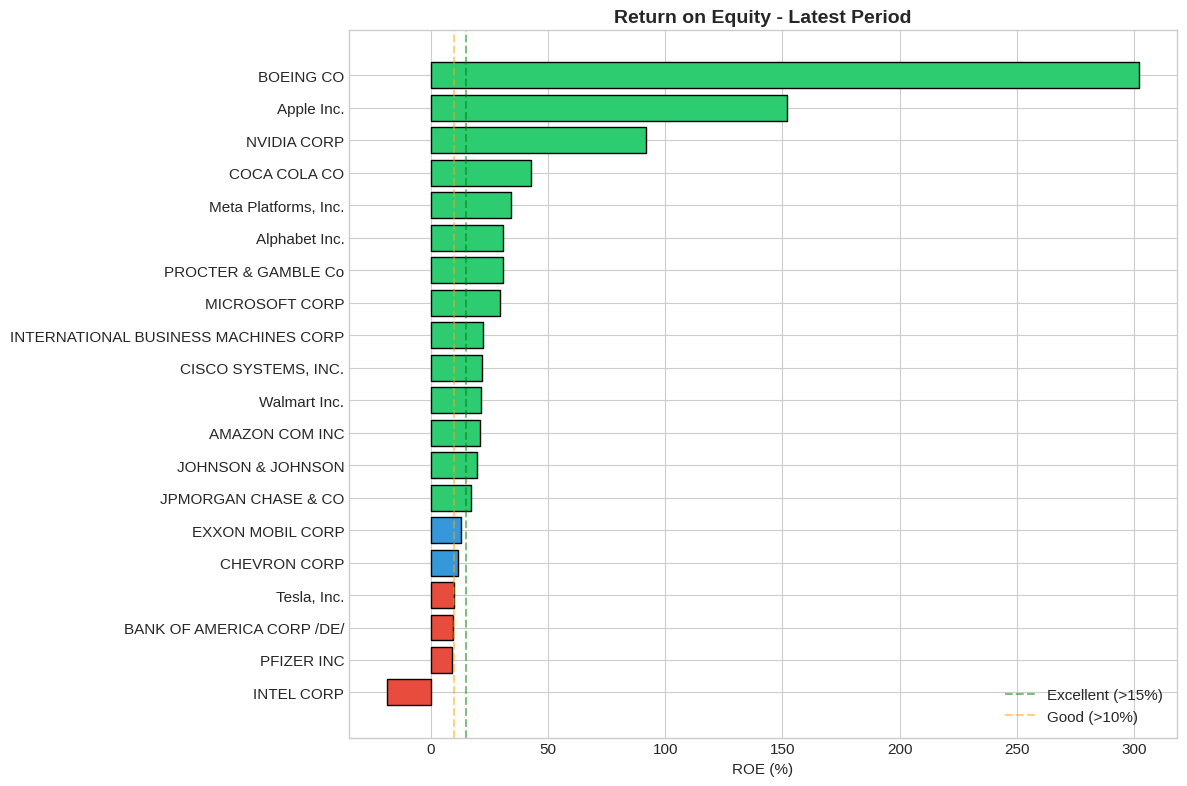

In [7]:
# ROE Visualization
fig, ax = plt.subplots(figsize=(12, 8))

roe_data = latest[['company', 'roe']].dropna().sort_values('roe', ascending=True)
colors = ['#2ecc71' if x > 0.15 else '#3498db' if x > 0.10 else '#e74c3c' for x in roe_data['roe']]

ax.barh(roe_data['company'], roe_data['roe'] * 100, color=colors, edgecolor='black')
ax.axvline(15, color='green', linestyle='--', alpha=0.5, label='Excellent (>15%)')
ax.axvline(10, color='orange', linestyle='--', alpha=0.5, label='Good (>10%)')
ax.set_xlabel('ROE (%)')
ax.set_title('Return on Equity - Latest Period', fontsize=14, fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig(FIG_PATH / 'fig_roe_ranking.png', dpi=150)
plt.show()

## 4. Correlation Matrix

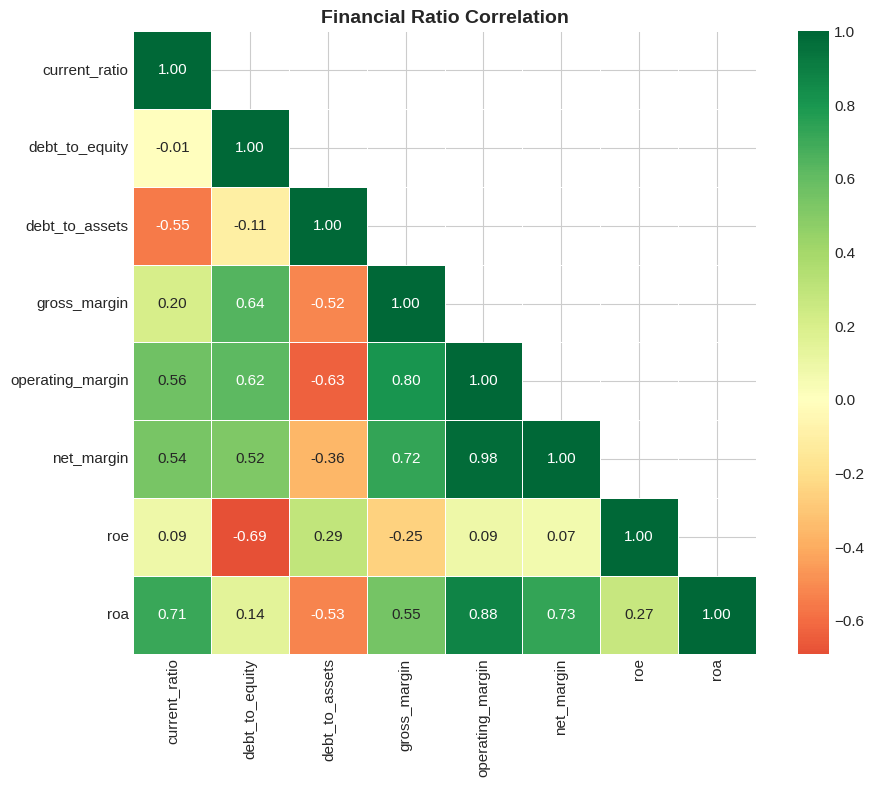

In [8]:
# Correlation between ratios - use all data for sufficient samples
all_ratios = conn.execute("""
    SELECT c.name as company, r.*
    FROM ratios r
    JOIN companies c ON r.cik = c.cik
""").fetchdf()

corr_matrix = all_ratios[ratios_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
# Use np.triu to mask upper triangle (show only lower)
import numpy as np
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            mask=mask, ax=ax, square=True, linewidths=0.5)
ax.set_title('Financial Ratio Correlation', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(FIG_PATH / 'fig_correlation.png', dpi=150)
plt.show()

## 5. Leverage vs Profitability Analysis

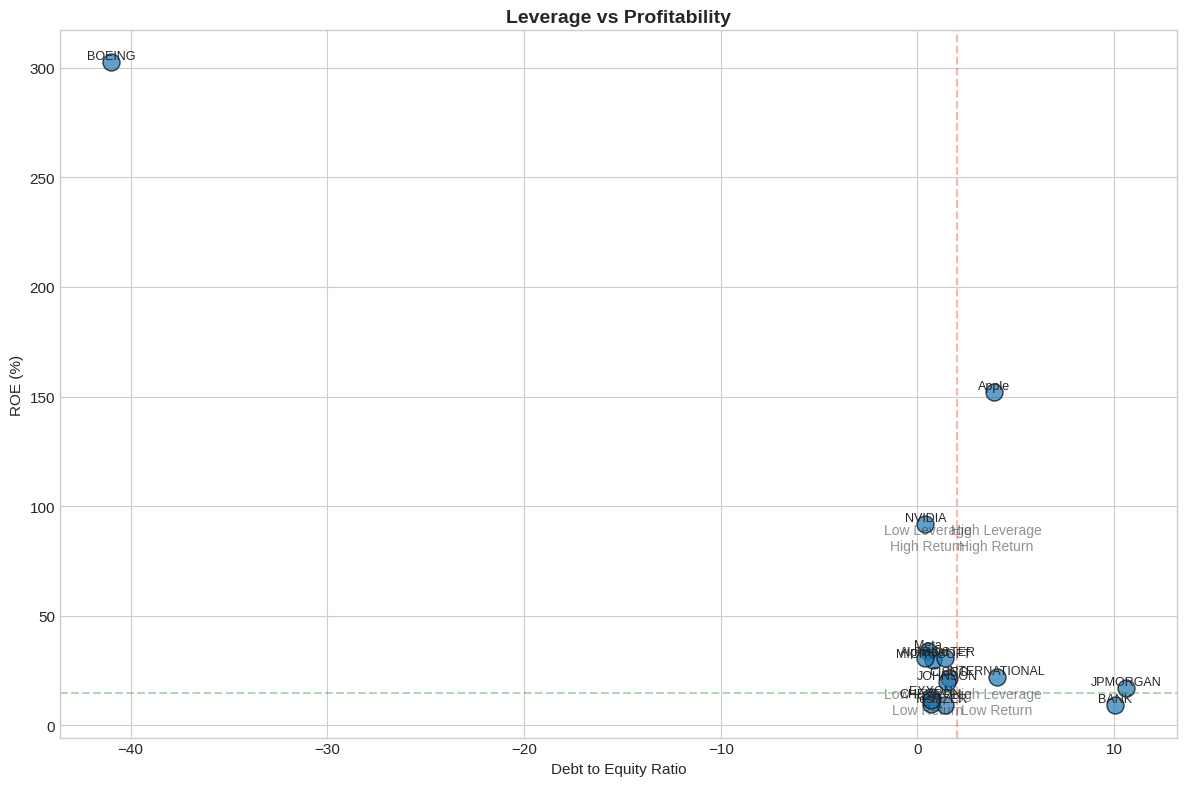

In [9]:
fig, ax = plt.subplots(figsize=(12, 8))

scatter_data = latest[['company', 'debt_to_equity', 'roe']].dropna()
# Filter extreme outliers for visualization
scatter_data = scatter_data[scatter_data['debt_to_equity'] < 15]

ax.scatter(scatter_data['debt_to_equity'], scatter_data['roe'] * 100, 
           s=150, alpha=0.7, edgecolor='black')

for _, row in scatter_data.iterrows():
    ax.annotate(row['company'].split()[0],  # First word only
                (row['debt_to_equity'], row['roe'] * 100),
                fontsize=9, ha='center', va='bottom')

ax.axhline(15, color='green', linestyle='--', alpha=0.3)
ax.axvline(2, color='red', linestyle='--', alpha=0.3)

ax.set_xlabel('Debt to Equity Ratio')
ax.set_ylabel('ROE (%)')
ax.set_title('Leverage vs Profitability', fontsize=14, fontweight='bold')

# Quadrants
ax.text(0.5, 80, 'Low Leverage\nHigh Return', fontsize=10, alpha=0.5, ha='center')
ax.text(4, 80, 'High Leverage\nHigh Return', fontsize=10, alpha=0.5, ha='center')
ax.text(0.5, 5, 'Low Leverage\nLow Return', fontsize=10, alpha=0.5, ha='center')
ax.text(4, 5, 'High Leverage\nLow Return', fontsize=10, alpha=0.5, ha='center')

plt.tight_layout()
plt.savefig(FIG_PATH / 'fig_leverage_vs_roe.png', dpi=150)
plt.show()

## 6. Time Trends

In [10]:
# Average ratio evolution over time
trends = conn.execute("""
    SELECT 
        YEAR(period_end) as year,
        AVG(roe) as avg_roe,
        AVG(net_margin) as avg_net_margin,
        AVG(debt_to_equity) as avg_d_e,
        AVG(current_ratio) as avg_current,
        COUNT(*) as n_companies
    FROM ratios
    GROUP BY YEAR(period_end)
    ORDER BY year
""").fetchdf()

print("=== Time Trends (averages) ===\n")
print(trends.round(3).to_string(index=False))

=== Time Trends (averages) ===

 year  avg_roe  avg_net_margin  avg_d_e  avg_current  n_companies
 2022    0.163           0.145      NaN          NaN           16
 2023    0.320           0.188    2.787        1.425           26
 2024    0.444           0.173    0.948        1.396           25
 2025    0.661           0.277    1.823        1.432            8


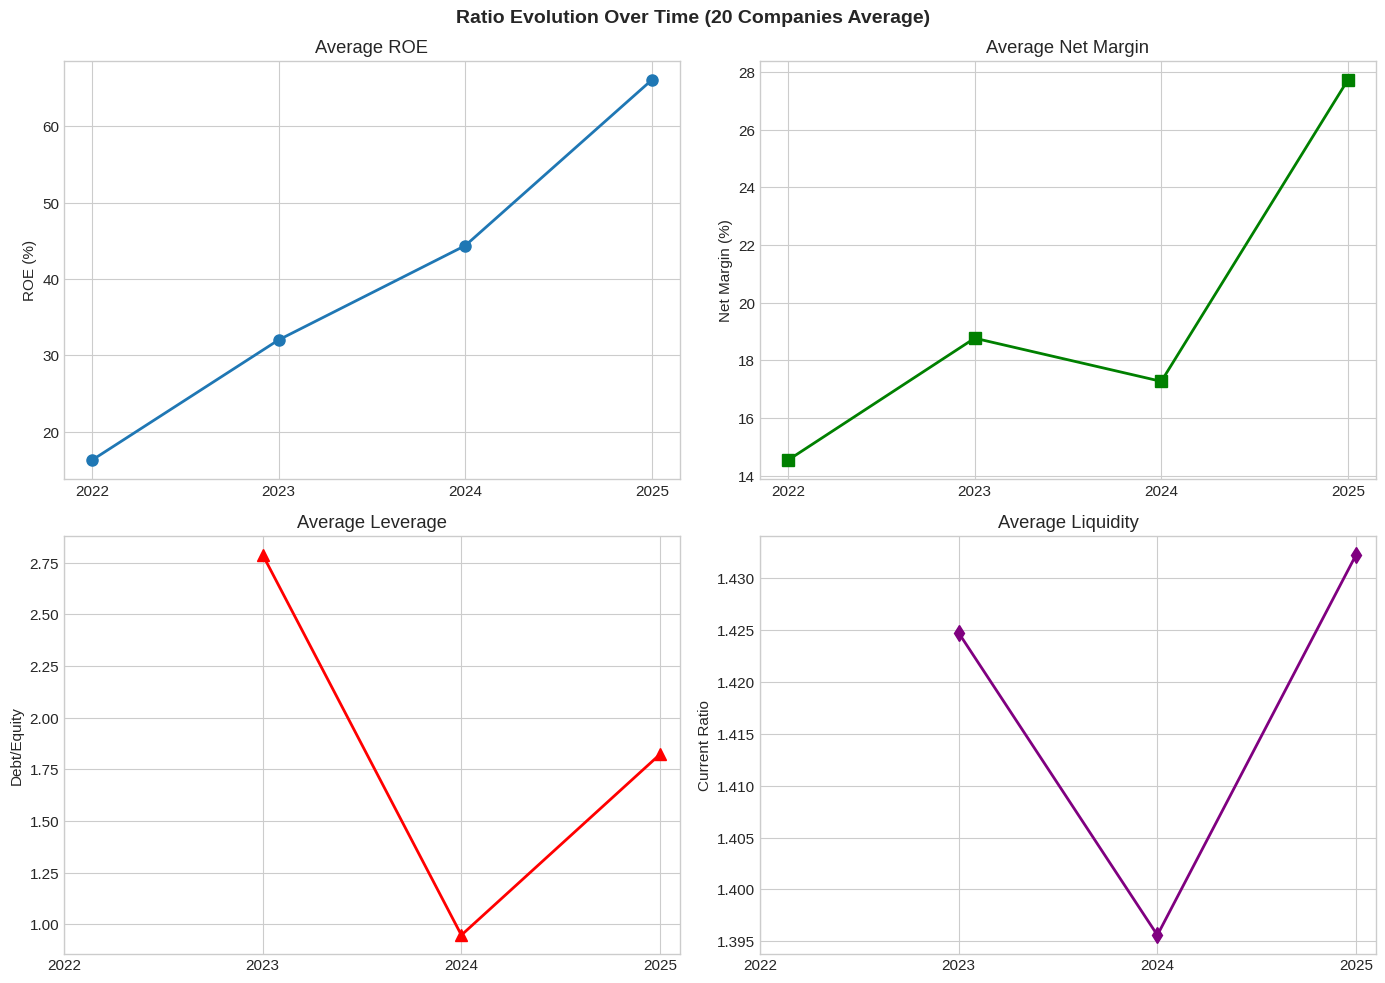

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ROE trend
ax = axes[0, 0]
ax.plot(trends['year'], trends['avg_roe'] * 100, marker='o', linewidth=2, markersize=8)
ax.set_ylabel('ROE (%)')
ax.set_title('Average ROE')
ax.set_xticks(trends['year'])

# Net Margin trend
ax = axes[0, 1]
ax.plot(trends['year'], trends['avg_net_margin'] * 100, marker='s', linewidth=2, markersize=8, color='green')
ax.set_ylabel('Net Margin (%)')
ax.set_title('Average Net Margin')
ax.set_xticks(trends['year'])

# D/E trend
ax = axes[1, 0]
ax.plot(trends['year'], trends['avg_d_e'], marker='^', linewidth=2, markersize=8, color='red')
ax.set_ylabel('Debt/Equity')
ax.set_title('Average Leverage')
ax.set_xticks(trends['year'])

# Current Ratio trend
ax = axes[1, 1]
ax.plot(trends['year'], trends['avg_current'], marker='d', linewidth=2, markersize=8, color='purple')
ax.set_ylabel('Current Ratio')
ax.set_title('Average Liquidity')
ax.set_xticks(trends['year'])

plt.suptitle('Ratio Evolution Over Time (20 Companies Average)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_PATH / 'fig_trends.png', dpi=150)
plt.show()

## 7. Outlier and Anomaly Detection

In [13]:
print("=== Potential Anomalies ===\n")

# Current ratio < 1 (liquidity issues)
low_liquidity = latest[latest['current_ratio'] < 1][['company', 'current_ratio']].dropna()
print("⚠️  Current Ratio < 1 (liquidity stress):")
for _, row in low_liquidity.iterrows():
    print(f"   {row['company']}: {row['current_ratio']:.2f}")

print()

# D/E > 5 (high leverage)
high_leverage = latest[latest['debt_to_equity'] > 5][['company', 'debt_to_equity']].dropna()
print("⚠️  Debt/Equity > 5 (high leverage):")
for _, row in high_leverage.iterrows():
    print(f"   {row['company']}: {row['debt_to_equity']:.2f}")

print()

# Negative ROE
negative_roe = latest[latest['roe'] < 0][['company', 'roe']].dropna()
print("🔴 Negative ROE:")
if len(negative_roe) > 0:
    for _, row in negative_roe.iterrows():
        print(f"   {row['company']}: {row['roe']*100:.1f}%")
else:
    print("   None")

print()

# ROE > 50% (exceptional or anomalous)
exceptional_roe = latest[latest['roe'] > 0.5][['company', 'roe']].dropna()
print("🟢 ROE > 50% (exceptional):")
if len(exceptional_roe) > 0:
    for _, row in exceptional_roe.iterrows():
        print(f"   {row['company']}: {row['roe']*100:.1f}%")
else:
    print("   None")

=== Potential Anomalies ===

⚠️  Current Ratio < 1 (liquidity stress):
   CISCO SYSTEMS, INC.: 1.00
   Apple Inc.: 0.89
   PROCTER & GAMBLE Co: 0.70
   Walmart Inc.: 0.82

⚠️  Debt/Equity > 5 (high leverage):
   BANK OF AMERICA CORP /DE/: 10.04
   JPMORGAN CHASE & CO: 10.61

🔴 Negative ROE:
   INTEL CORP: -18.9%

🟢 ROE > 50% (exceptional):
   Apple Inc.: 151.9%
   BOEING CO: 302.4%
   NVIDIA CORP: 91.9%


## 8. Synthetic Risk Profile

In [14]:
def risk_score(row):
    """Score 0-100, higher = riskier"""
    score = 50  # baseline
    
    # Liquidity
    if pd.notna(row['current_ratio']):
        if row['current_ratio'] < 1:
            score += 20
        elif row['current_ratio'] < 1.5:
            score += 10
        elif row['current_ratio'] > 2:
            score -= 10
    
    # Leverage
    if pd.notna(row['debt_to_equity']):
        if row['debt_to_equity'] > 5:
            score += 20
        elif row['debt_to_equity'] > 2:
            score += 10
        elif row['debt_to_equity'] < 1:
            score -= 10
    
    # Profitability
    if pd.notna(row['roe']):
        if row['roe'] < 0:
            score += 25
        elif row['roe'] < 0.05:
            score += 10
        elif row['roe'] > 0.20:
            score -= 15
    
    # Cash flow
    if pd.notna(row['ocf_to_debt']):
        if row['ocf_to_debt'] < 0.1:
            score += 15
        elif row['ocf_to_debt'] > 0.3:
            score -= 10
    
    return max(0, min(100, score))

latest['risk_score'] = latest.apply(risk_score, axis=1)

print("=== Risk Score (0=safe, 100=risky) ===\n")
risk_rank = latest[['company', 'risk_score']].sort_values('risk_score', ascending=False)
print(risk_rank.to_string(index=False))

=== Risk Score (0=safe, 100=risky) ===

                             company  risk_score
                          INTEL CORP          85
                 JPMORGAN CHASE & CO          85
           BANK OF AMERICA CORP /DE/          85
                   JOHNSON & JOHNSON          60
                          PFIZER INC          60
                 PROCTER & GAMBLE Co          55
INTERNATIONAL BUSINESS MACHINES CORP          55
                        Walmart Inc.          55
                 CISCO SYSTEMS, INC.          55
                          Apple Inc.          55
                           BOEING CO          50
                      AMAZON COM INC          45
                        COCA COLA CO          45
                    EXXON MOBIL CORP          40
                        CHEVRON CORP          40
                      MICROSOFT CORP          25
                         Tesla, Inc.          20
                       Alphabet Inc.          15
                Meta Platform

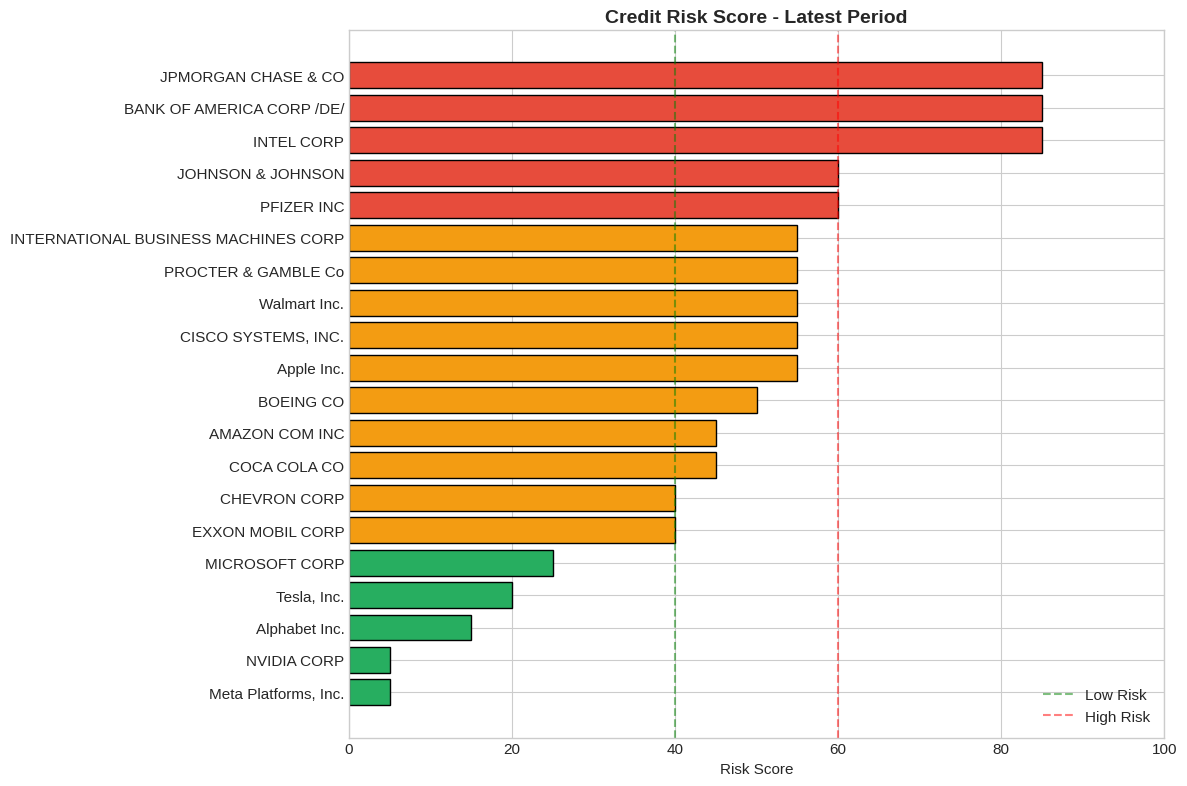

In [15]:
# Risk Score Visualization
fig, ax = plt.subplots(figsize=(12, 8))

risk_sorted = latest[['company', 'risk_score']].sort_values('risk_score', ascending=True)
colors = ['#27ae60' if x < 40 else '#f39c12' if x < 60 else '#e74c3c' for x in risk_sorted['risk_score']]

ax.barh(risk_sorted['company'], risk_sorted['risk_score'], color=colors, edgecolor='black')
ax.axvline(40, color='green', linestyle='--', alpha=0.5, label='Low Risk')
ax.axvline(60, color='red', linestyle='--', alpha=0.5, label='High Risk')
ax.set_xlabel('Risk Score')
ax.set_title('Credit Risk Score - Latest Period', fontsize=14, fontweight='bold')
ax.legend()
ax.set_xlim(0, 100)

plt.tight_layout()
plt.savefig(FIG_PATH / 'fig_risk_score.png', dpi=150)
plt.show()

## 9. Summary Insights

In [16]:
print("""
╔══════════════════════════════════════════════════════════════════╗
║                     SUMMARY INSIGHTS                             ║
╠══════════════════════════════════════════════════════════════════╣
""")

best_roe = latest.loc[latest['roe'].idxmax()]
worst_roe = latest.loc[latest['roe'].idxmin()] if latest['roe'].min() < 0.10 else None
safest = latest.loc[latest['risk_score'].idxmin()]
riskiest = latest.loc[latest['risk_score'].idxmax()]

print(f"  🏆 Best ROE: {best_roe['company']} ({best_roe['roe']*100:.1f}%)")
print(f"  🛡️  Safest: {safest['company']} (risk score: {safest['risk_score']:.0f})")
print(f"  ⚠️  Riskiest: {riskiest['company']} (risk score: {riskiest['risk_score']:.0f})")
print(f"\n  📊 Average ROE: {latest['roe'].mean()*100:.1f}%")
print(f"  📊 Average D/E: {latest['debt_to_equity'].mean():.2f}")

print("""
╚══════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════╗
║                     SUMMARY INSIGHTS                             ║
╠══════════════════════════════════════════════════════════════════╣

  🏆 Best ROE: BOEING CO (302.4%)
  🛡️  Safest: Meta Platforms, Inc. (risk score: 5)
  ⚠️  Riskiest: INTEL CORP (risk score: 85)

  📊 Average ROE: 43.5%
  📊 Average D/E: -0.15

╚══════════════════════════════════════════════════════════════════╝



In [17]:
conn.close()
print("✓ Analysis complete. Figures saved to notebooks/")

✓ Analysis complete. Figures saved to notebooks/
